# **길이에 따른 생선 무게 예측하기**

## **1. 데이터 수집**  

*   라이브러리 가져오기
*   데이터 가져오기



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('Fish.csv')

In [6]:
df['Species'].value_counts()

,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


In [21]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

## **2. 데이터 가공**  

*   학습용 데이터 추출  
*   데이터 분할  
*   인공지능 학습시, <font color='red'>X->2차원 / y->1차원</font> 형태를 학습


In [30]:
#fish_x=df.loc[df['Species']=='Perch],['Length1']]
#fish_y=df.loc[df['Species']=='Perch],'Weight']
fish_x=df[df['Species']=='Perch'][['Length1']]
fish_y=df[df['Species']=='Perch']['Weight']

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(fish_x,fish_y,random_state=42)

# **3. 인공지능 모델 구현**  
<font color='red'>**선형회귀**</font>  
주어진 데이터(독립변수, X)를 바탕으로 y값을 예측하는 것이 목적인 알고리즘  
즉, X와 y의 관계를 예측할 수 있는 **기울기(a) 및 절편(b)** 값을 찾는 것이 목적  

<font color='green'>Ex) 공부 시간(X)과 시험 점수(y) 관계  
X: 1,2,3,4,5  
y: 60,65,70,75,80  

공부시간이 1시간 늘어나면 점수는 5점이 증가할 것이다라고 예측</font>  
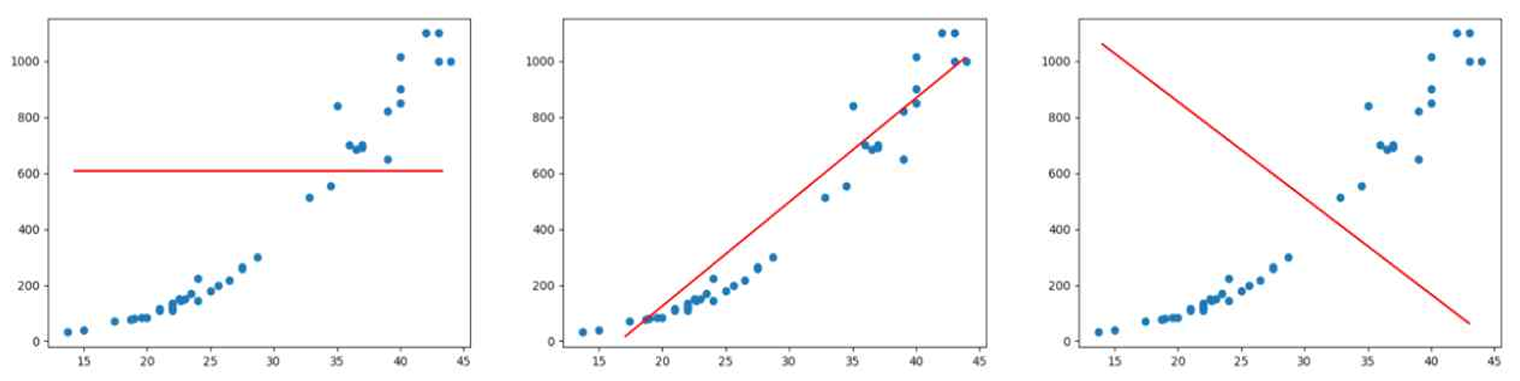

*   라이브러리 import

In [16]:
from sklearn.linear_model import LinearRegression

*   모델 생성

In [28]:
lr=LinearRegression()

*   모델 훈련(훈련용 데이터)

In [32]:
lr.fit(X_train,y_train)

LinearRegression()

*   모델 평가  
> **Overfitting(과대적합)**  
><font color='blue'>모델이 훈련 데이터에만 너무 맞게 학습된 상태</font>, 문제 조금만 바뀌면 틀림  
모델 단순화 / 데이터 양 늘리기 / 정규화 등으로 해결      
>
> **Underfitting(과소적합)**  
><font color='green'>모델이 데이터를 제대로 학습하지 못한 상태</font>, 문제 유형도 이해 못함  
모델 복잡하게 / 더 많은 feature 사용 / 학습량 늘리기로 해결







* **<font color='red'>결정계수(R²)</font>**  
모델이 데이터를 얼마나 잘 설명하는지의 비율  
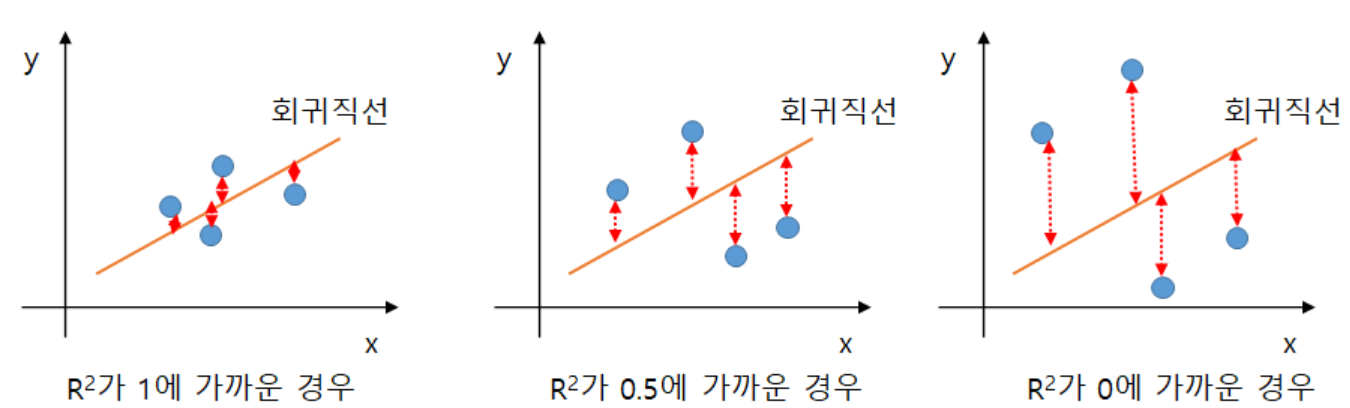

In [35]:
print(f"Train 데이터 점수는 {lr.score(X_train,y_train)}")
print(f"Test 데이터 점수는 {lr.score(X_test,y_test)}")

Train 데이터 점수는 0.9372052934649839
Test 데이터 점수는 0.8337978694307249


**회귀 평가지표**  
*   <font color='green'>MAE</font> 평균 절대 오차
*   <font color='green'>MSE</font> 평균 제곱 오차
*   <font color='green'>RMSE</font> 평균 제곱 오차의 루트 값

In [58]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

y_pred=lr.predict(X_test)
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

93.95078840348118
16682.139190645183
129.15935579990008


*   결과 예측 **[45cm의 농어는 몇 kg일까?]**

In [36]:
lr.predict([[45]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1167.94603172])

*   기울기 / 절편 확인

In [37]:
print(lr.coef_)
print(lr.intercept_)

[40.93867005]
-674.294120691525


*   시각화를 통한 확인

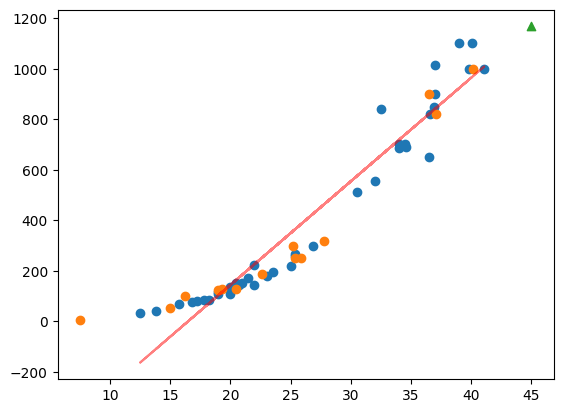

In [59]:
plt.scatter(X_train,y_train)
plt.scatter(X_test,y_test)
plt.plot(X_train,lr.coef_*X_train+lr.intercept_, c='r',alpha=.5)
plt.scatter(45,1167, marker="^")
plt.show()

*   <font color='red'>**문제 발생**</font>   
농어의 무게가 음수인 경우가 발생 -> <font color='blue'>해결방법은?</font>

# **4. 다항 회귀 및 다중 회귀**  
*   <font color='blue'>다항 회귀</font>  
독립 변수는 한 개이지만, 해당 변수의 거듭제곱 항을 활용해 예측하는 모델  

*   <font color='green'>다중 회귀</font>  
한 개의 종속 변수를 여러 개의 독립 변수로 예측하는 선형 관계 모델  
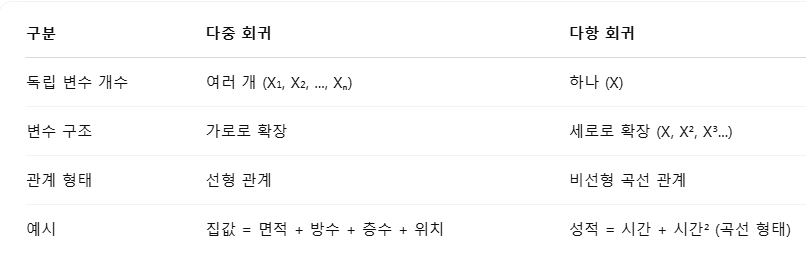